In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df= sns.load_dataset('titanic')

In [54]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn. cluster import KMeans
X = df[['age','fare']]
X.age.fillna(value= X['age'].mean(), inplace=True)
# scaled data
scaler= StandardScaler()
X_scaled = scaler.fit_transform(X)
# perform clustering
model = KMeans(n_clusters=5)
model.fit(X_scaled)
df['cluster']=model.labels_


C:\Users\AD\AppData\Local\Temp\ipykernel_5824\2676361528.py:4: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\AD\AppData\Local\Temp\ipykernel_5824\2676361528.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [56]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,cluster
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,1
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,0


In [57]:
df['cluster'].unique()

array([0, 1, 3, 2, 4], dtype=int32)

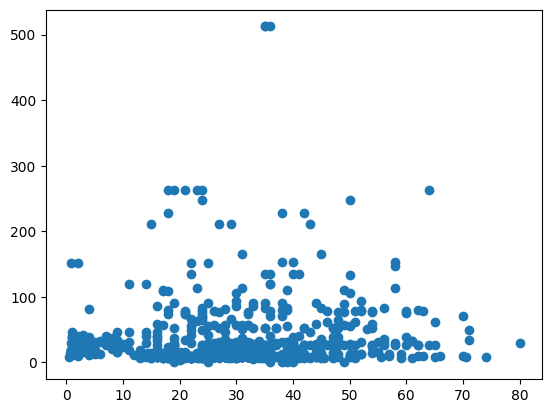

In [58]:
plt.scatter(df['age'],df['fare'])

Text(0, 0.5, 'fare')

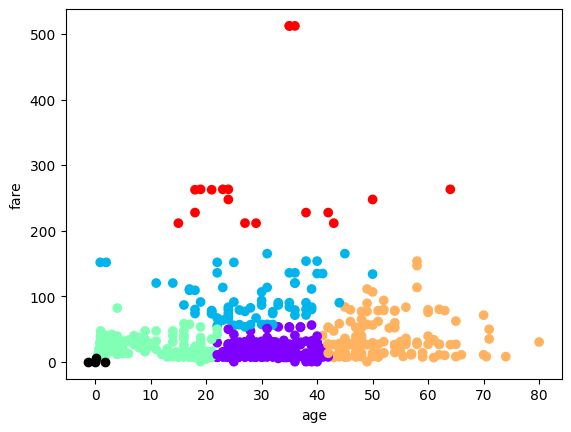

In [59]:
plt.scatter(df['age'],df['fare'],c=df['cluster'], cmap='rainbow')
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],color='black')
plt.xlabel('age')
plt.ylabel('fare')

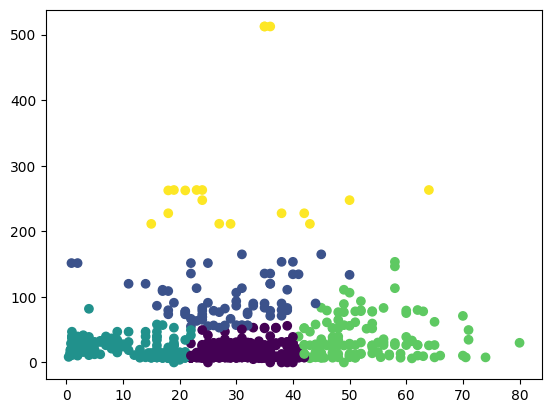

In [60]:
plt.scatter(df['age'],df['fare'],c=df['cluster'])

In [61]:

import plotly.express as px
fig = px.scatter(df,x='age',y='fare', color='cluster')
fig.show()

In [62]:
import plotly.express as px
fig = px.scatter_3d(df,x='age',y='fare',z='pclass',color='cluster')
fig.show()

In [63]:
fig = px.parallel_coordinates(df,color='cluster')
fig.show()

In [64]:
pip install joblib


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [65]:
#saving the model
import joblib
joblib.dump(model,'kmeansclustering.joblib')

['kmeansclustering.joblib']

In [66]:
model_loaded=joblib.load('kmeansclustering.joblib')

In [67]:
import seaborn as sns

In [68]:
df_1 = sns.load_dataset('tips')
df_1

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [70]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(df_1['smoker'])
df_1['smoker']= le.transform(df_1['smoker'])

In [71]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(df_1['time'])
df_1['time']= le.transform(df_1['time'])

In [72]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(df_1['day'])
df_1['day']= le.transform(df_1['day'])

In [73]:
X = df_1.drop(columns=['sex'])
y = df_1['sex']

In [74]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    int64   
 4   day         244 non-null    int64   
 5   time        244 non-null    int64   
 6   size        244 non-null    int64   
dtypes: category(1), float64(2), int64(4)
memory usage: 11.9 KB


In [ ]:
df_1.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [75]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X,y)

DecisionTreeClassifier()

In [76]:
joblib.dump(model,'tipswalamodel.joblib')

['tipswalamodel.joblib']

In [78]:
joblib.load('tipswalamodel.joblib')

DecisionTreeClassifier()

In [80]:
import pickle
# save the model
with open('model.pkl','wb') as f:
    pickle.dump(model, f)
    
# load the model
with open('model.pkl','rb') as f:
    loaded_model=pickle.load(f)